In [30]:
# Chunk 0 - Auto-install missing packages
# Checks that all packages needed by this notebook are installed, and installs
# any that are missing before the imports below run. Safe to re-run.

import importlib
import subprocess
import sys

# Map: module name used in `import ...`  ->  package name used by pip install
REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "cv2": "opencv-python",
    "PIL": "Pillow",
    "datumaro": "datumaro",
    "yaml": "PyYAML",
    "sklearn": "scikit-learn",
    "tqdm": "tqdm",
}

def install_missing_packages(packages: dict) -> None:
    """
    Check whether each required package can be imported, and pip install
    any that are missing.

    Args:
        packages (dict): mapping of {import_name: pip_install_name}
    """
    missing = []
    for import_name, pip_name in packages.items():
        try:
            importlib.import_module(import_name)
        except ImportError:
            missing.append(pip_name)

    if missing:
        print(f"Installing missing packages: {missing}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
        print("Finished installing missing packages.")
    else:
        print("All required packages are already installed.")

install_missing_packages(REQUIRED_PACKAGES)


All required packages are already installed.


In [31]:
# Chunk 1 - Core imports

# Core Python
import os
import glob
import json
import random
import time
from collections import Counter, defaultdict
from typing import Dict, Any, List, Tuple
from pathlib import Path
import re
import shutil
# Math & Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
from PIL import Image

# Annotation / Dataset Handling 
import datumaro as dm
from difflib import get_close_matches  # used by link_images_to_dataset()
from sklearn.model_selection import StratifiedGroupKFold, GroupKFold
from tqdm import tqdm

import yaml




In [33]:
# Chunk 2 - Config and path setup

# If only using the testing-dataset used here, dont change anything. If youre adding your own dataset, add the path here
# This chunk checks that the paths are working and checking the structures of the .json file with the annotations
# and the number of classes

def find_repo_root(start: Path = None, marker: str = ".git") -> Path:
    """
    Walk upward from `start` (default: current working directory) until a
    directory containing `marker` is found.

    This lets the notebook use paths relative to the repo instead of a
    hardcoded absolute path, so it works the same whether it's run from
    a laptop, a server, or someone else's clone of the repo.
    """
    start = start or Path.cwd()
    for directory in [start, *start.parents]:
        if (directory / marker).exists():
            return directory
    raise FileNotFoundError(
        f"Could not find repo root (looked for a parent directory containing '{marker}')."
    )


REPO_ROOT = find_repo_root()
BASE_DIR = REPO_ROOT / "data" / "annotations"  # relative to the repo root

CONFIG = {
    "ANNOTATIONS_FILE": BASE_DIR / "test_annotations/annotations/instances_default.json",
    "IMAGES_DIR": BASE_DIR / "test_annotations/images/default",
}

def get_dataset_paths() -> tuple:
    """Get full paths for the dataset and verify structure.

    Returns:
        tuple: (annotations_path, images_path, data)
    """
    annotations_path = CONFIG["ANNOTATIONS_FILE"]
    images_path = CONFIG["IMAGES_DIR"]

    if not annotations_path.exists():
        raise FileNotFoundError(f"Annotations file not found: {annotations_path}")
    if not images_path.exists():
        raise FileNotFoundError(f"Images directory not found: {images_path}")

    print(f"Using annotations: {annotations_path}")
    print(f"Using images: {images_path}")

    print("\nVerifying JSON structure...")
    with open(annotations_path, 'r') as f:
        data = json.load(f)
        print("Top-level keys:", list(data.keys()))

        if 'items' in data:
            print("\nHas 'items' key (contains annotations)")
            print(f"Number of items: {len(data['items'])}")

            if len(data['items']) > 0:
                first_item = data['items'][0]
                print("\nFirst item structure:")
                print("Keys in first item:", list(first_item.keys()))

                if 'annotations' in first_item and first_item['annotations']:
                    print("\nFirst annotation structure:")
                    print("Keys in first annotation:", list(first_item['annotations'][0].keys()))
                    print("\nExample annotation:", json.dumps(first_item['annotations'][0], indent=2))
        else:
            print("Missing 'items' key")

        if 'categories' in data:
            print("\nHas 'categories' key")
            print(f"Number of categories: {len(data['categories'])}")
        else:
            print("Missing 'categories' key")

        if 'info' in data:
            print("\n Has 'info' key")

    return annotations_path, images_path, data


annotations_path, images_path, annotation_data = get_dataset_paths()

Using annotations: /scratch/disk4/crab_model_gina/crabs-on-camera/data/annotations/test_annotations/annotations/instances_default.json
Using images: /scratch/disk4/crab_model_gina/crabs-on-camera/data/annotations/test_annotations/images/default

Verifying JSON structure...
Top-level keys: ['licenses', 'info', 'categories', 'images', 'annotations']
Missing 'items' key

Has 'categories' key
Number of categories: 8

 Has 'info' key


In [34]:
# Chunk 3 - Load and validate dataset
# This chunk validates and loads the dataset, and checks the first annotation
def load_and_validate_dataset() -> dm.Dataset:
    """
    Load and validate the dataset defined in CONFIG.

    Returns:
        dm.Dataset: the loaded Datumaro dataset
    """
    annotations_path = CONFIG["ANNOTATIONS_FILE"]
    images_path = CONFIG["IMAGES_DIR"]

    print("=" * 80)
    print("Loading dataset...")
    print(f"Annotations: {annotations_path}")
    print(f"Images: {images_path}")

    # Load raw JSON
    
    with open(annotations_path, "r") as f:
        data = json.load(f)

    # Basic validation
    if not isinstance(data.get("categories"), list):
        raise ValueError("JSON is not COCO-style (missing 'categories' list).")
    print("Detected COCO format.")

    # Load dataset using Datumaro
    dataset = dm.Dataset.import_from(str(annotations_path), "coco")
    print(f"Loaded {len(dataset)} items")

    # Label summary
    print("\nLabels:")
    for cat in data["categories"]:
        print(f"  {cat['id']}: {cat['name']}")

    # Find first annotated image
    first_annotated = next((i for i in dataset if len(i.annotations) > 0), None)
    if first_annotated:
        print(f"\nFirst annotated image: {first_annotated.id}")
        print(f"Total annotations: {len(first_annotated.annotations)}")
    else:
        print("Warning: no annotated items found!")

    print("=" * 80)
    print("Dataset loaded and validated successfully.")

    return dataset


dataset = load_and_validate_dataset()

Loading dataset...
Annotations: /scratch/disk4/crab_model_gina/crabs-on-camera/data/annotations/test_annotations/annotations/instances_default.json
Images: /scratch/disk4/crab_model_gina/crabs-on-camera/data/annotations/test_annotations/images/default
Detected COCO format.
Loaded 541 items

Labels:
  1: Decapods
  2: Gadines
  3: Flounders
  4: Labrids
  5: Pelagic gobies
  6: Benthic gobies
  7: Sharks
  8: Lotids

First annotated image: NO_2025_3007_GarnRuse_Lovund_LO3_RA1_L9_frame_9
Total annotations: 10
Dataset loaded and validated successfully.


In [35]:
# Chunk 4 - Convert RLE masks (CVAT/COCO 1.0) into YOLO-style bounding boxes
# This also allows you to specify which species to import

def convert_masks_to_yolo_boxes(
    dataset: dm.Dataset,
    target_label: int = 1,          # 1 = Decapods
    target_species: str = "crab",   # Only keep Decapods with species=crab
    swap_dimensions: bool = False,  # Default = False (Datumaro gives (H, W))
    iou_threshold: float = 0.8
) -> dm.Dataset:
    """
    Convert true RLE masks to YOLO-style bounding boxes.
    Keeps only Decapods that have 'Species' = 'Crab' (case-insensitive).
    Corrects for Datumaro (H, W) ordering to avoid swapped dimensions.
    """

    def deduplicate_boxes(annotations, iou_threshold=0.8):
        """Remove duplicate boxes that heavily overlap, IoU > threshold."""
        unique, seen = [], []
        for ann in annotations:
            if not isinstance(ann, dm.Bbox):
                unique.append(ann)
                continue
            x, y, w, h = ann.x, ann.y, ann.w, ann.h
            box = np.array([x, y, x + w, y + h])
            duplicate = False
            for s in seen:
                xx1 = max(box[0], s[0])
                yy1 = max(box[1], s[1])
                xx2 = min(box[2], s[2])
                yy2 = min(box[3], s[3])
                inter = max(0, xx2 - xx1) * max(0, yy2 - yy1)
                union = (w * h) + ((s[2] - s[0]) * (s[3] - s[1])) - inter
                iou = inter / union if union > 0 else 0
                if iou > iou_threshold:
                    duplicate = True
                    break
            if not duplicate:
                seen.append(box)
                unique.append(ann)
        return unique

    print("=" * 100)
    print("Converting dataset (keeping only Decapod:Crab masks)...")

    start_time = time.time()
    total_items = len(dataset)
    converted_items, success, fail = [], 0, 0
    printed_example = False

    for item in dataset:
        converted_annotations = []

        # Datumaro returns (height, width)
        img_h, img_w = item.media.size

        # Optionally swap if dataset has reversed ordering
        if swap_dimensions:
            img_w, img_h = img_h, img_w

        for ann in item.annotations:
            if ann.type.name == "mask" and not hasattr(ann, "points"):
                # Filter: only target class
                if ann.label != target_label:
                    continue

                # Filter: species attribute contains target_species
                attrs = {k.lower(): str(v).lower() for k, v in ann.attributes.items()}
                species_attr = attrs.get("species", "")
                if target_species.lower() not in species_attr:
                    continue

                try:
                    x, y, w, h = ann.get_bbox()
                    if w <= 0 or h <= 0:
                        fail += 1
                        continue

                    converted_annotations.append(
                        dm.Bbox(x, y, w, h, label=ann.label, attributes=ann.attributes)
                    )
                    success += 1

                    # Print the first example for inspection
                    if not printed_example:
                        printed_example = True
                        x_center = (x + w / 2) / img_w
                        y_center = (y + h / 2) / img_h
                        w_norm = w / img_w
                        h_norm = h / img_h
                        print("\nExample conversion (first valid crab mask):")
                        print(f"   Image ID: {item.id}")
                        print(f"   Image size: {img_w}x{img_h}")
                        print(f"   Species: {species_attr}")
                        print(f"   Original bbox: [x={x:.1f}, y={y:.1f}, w={w:.1f}, h={h:.1f}]")
                        print(f"   YOLO normalized: "
                              f"(x={x_center:.4f}, y={y_center:.4f}, w={w_norm:.4f}, h={h_norm:.4f})")

                except Exception as e:
                    fail += 1
                    print(f"Error converting mask in {item.id}: {e}")

        # Deduplicate overlapping boxes
        before = len(converted_annotations)
        converted_annotations = deduplicate_boxes(converted_annotations, iou_threshold)
        after = len(converted_annotations)
        if after < before:
            print(f"Deduplicated {before - after} overlapping boxes in {item.id}")

        converted_items.append(item.wrap(annotations=converted_annotations, media=item.media))

    elapsed = time.time() - start_time
    print("Conversion complete")
    print(f"   Total images: {total_items:,}")
    print(f"   Boxes created (crabs only): {success:,}")
    print(f"   Failed masks: {fail:,}")
    print(f"   Time elapsed: {elapsed:.1f}s")
    print("=" * 100)

    return dm.Dataset.from_iterable(
        converted_items,
        categories=dataset.categories(),
        media_type=dm.Image
    )


converted_dataset = convert_masks_to_yolo_boxes(
    dataset,
    target_label=0,        # Decapods label
    target_species="crab",
    swap_dimensions=False  # keep False unless proven needed
)



Converting dataset (keeping only Decapod:Crab masks)...

Example conversion (first valid crab mask):
   Image ID: NO_2025_3007_GarnRuse_Lovund_LO3_RA1_L9_frame_9
   Image size: 1920x1080
   Species: crab
   Original bbox: [x=1106.0, y=867.0, w=234.0, h=203.0]
   YOLO normalized: (x=0.6370, y=0.8968, w=0.1219, h=0.1880)
Conversion complete
   Total images: 541
   Boxes created (crabs only): 403
   Failed masks: 0
   Time elapsed: 0.0s


In [36]:
# Chunk 5 - Link images to the frames
def link_images_to_dataset(converted_dataset: dm.Dataset) -> dm.Dataset:
    """
    Link image files from CONFIG paths to the converted dataset.
    Uses fuzzy matching to handle minor filename differences.

    Args:
        converted_dataset (dm.Dataset): output from convert_masks_to_yolo_boxes()

    Returns:
        dm.Dataset: dataset with media attached
    """
    print("=" * 100)
    print("Linking images for dataset...")

    images_path = CONFIG["IMAGES_DIR"]
    print(f"Looking in: {images_path}")

    # Collect all available image files
    image_files = {
        os.path.splitext(f.lower())[0]: os.path.join(images_path, f)
        for f in os.listdir(images_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    }

    linked_items = []
    unmatched = []

    for item in converted_dataset:
        base_id = os.path.basename(item.id).lower()
        media = None

        # Try exact match
        if base_id in image_files:
            media = dm.Image.from_file(path=image_files[base_id])
        else:
            # Fuzzy match (handles small filename differences)
            match = get_close_matches(base_id, image_files.keys(), n=1, cutoff=0.7)
            if match:
                media = dm.Image.from_file(path=image_files[match[0]])
            else:
                unmatched.append(item.id)

        linked_items.append(item.wrap(media=media))

    # Build dataset with media attached
    linked_dataset = dm.Dataset.from_iterable(
        linked_items,
        categories=converted_dataset.categories(),
    )

    print("Linked dataset created.")
    print(f"   Total items: {len(linked_dataset)}")
    print(f"   Unmatched items: {len(unmatched)}")
    if unmatched:
        print(f"   Example unmatched: {unmatched[:5]}")

    print("=" * 100)
    print("Dataset linked with images successfully.")

    return linked_dataset


linked_dataset = link_images_to_dataset(converted_dataset)

Linking images for dataset...
Looking in: /scratch/disk4/crab_model_gina/crabs-on-camera/data/annotations/test_annotations/images/default
Linked dataset created.
   Total items: 541
   Unmatched items: 0
Dataset linked with images successfully.


Displaying first annotated image from dataset...
Showing: /scratch/disk4/crab_model_gina/crabs-on-camera/data/annotations/test_annotations/images/default/NO_2025_3007_GarnRuse_Lovund_LO3_RA1_L9_frame_9.jpg


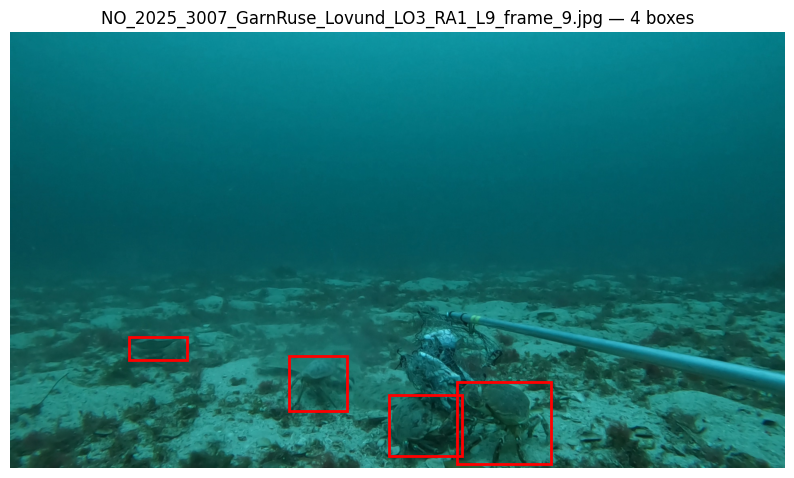

Display complete.


In [37]:
# Chunk 6 - Preview the first converted bounding box
def show_first_bbox(dataset: dm.Dataset) -> None:
    """
    Display the first annotated image from the dataset.
    Supports ann.bbox and ann.points formats.

    Args:
        dataset (dm.Dataset): a Datumaro dataset with linked media
    """
    print("=" * 100)
    print("Displaying first annotated image from dataset...")

    found = False
    for item in dataset:
        if len(item.annotations) > 0 and hasattr(item.media, "path") and item.media.path:
            print(f"Showing: {item.media.path}")
            img = Image.open(item.media.path)
            fig, ax = plt.subplots(figsize=(10, 6))
            ax.imshow(img)

            for ann in item.annotations:
                # --- Handle ann.bbox format ---
                if hasattr(ann, "bbox") and ann.bbox:
                    x, y, w, h = ann.bbox
                    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
                    ax.add_patch(rect)
                # --- Handle ann.points format (x_min, y_min, x_max, y_max) ---
                elif hasattr(ann, "points") and len(ann.points) >= 4:
                    x1, y1, x2, y2 = ann.points[:4]
                    w, h = x2 - x1, y2 - y1
                    rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor='r', facecolor='none')
                    ax.add_patch(rect)

            plt.title(f"{os.path.basename(item.media.path)} — {len(item.annotations)} boxes")
            plt.axis("off")
            plt.show()
            found = True
            break  # stop after first image

    if not found:
        print("No valid image with annotations found in dataset.")

    print("=" * 100)
    print("Display complete.")


show_first_bbox(linked_dataset)



In [ ]:
# Chunk 7 - Compare converted boxes against original masks
def visualize_mask_vs_bbox(
    original_dataset: dm.Dataset,
    converted_dataset: dm.Dataset,
    sample_ids: list = None,
    target_labels: list = None,
    n_samples: int = 3,
):
    """
    Compare original RLE/polygon masks with converted bounding boxes.

    Args:
        original_dataset (dm.Dataset): raw RLE/polygon dataset
        converted_dataset (dm.Dataset): YOLO-style bbox dataset
        sample_ids (list, optional): Specific item IDs to visualize.
        target_labels (list, optional): Labels to visualize (default: all in dataset)
        n_samples (int): Number of random annotated samples to visualize.
    """
    print("=" * 120)
    print("Visualizing mask -> bbox comparison...")

    # Collect annotated items
    original_items = [item for item in original_dataset if len(item.annotations) > 0]
    if not original_items:
        print("No annotated items found in dataset.")
        return

    # Choose sample items
    if sample_ids is None:
        sample_items = random.sample(original_items, min(n_samples, len(original_items)))
    else:
        sample_items = [i for i in original_items if i.id in sample_ids]

    n = len(sample_items)
    fig, axes = plt.subplots(n, 2, figsize=(18, 6 * n))
    if n == 1:
        axes = np.array([axes])

    fig.suptitle("Mask -> Bounding Box Conversion Validation", fontsize=18, y=0.95)

    for idx, orig_item in enumerate(sample_items):
        conv_item = next((ci for ci in converted_dataset if ci.id == orig_item.id), None)
        if conv_item is None:
            print(f"No converted item found for ID: {orig_item.id}")
            continue

        # Load the image
        image_path = None
        if hasattr(orig_item.media, "path") and orig_item.media.path:
            image_path = orig_item.media.path
        elif hasattr(conv_item.media, "path") and conv_item.media.path:
            image_path = conv_item.media.path

        if not image_path or not os.path.exists(image_path):
            print(f"No image found for {orig_item.id}")
            continue

        image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)

        # LEFT: original masks
        ax1 = axes[idx, 0]
        ax1.imshow(image)
        ax1.set_title(f"Original Masks — {os.path.basename(orig_item.id)}", fontsize=14)

        mask_count = 0
        for ann in orig_item.annotations:
            if target_labels is None or ann.label in target_labels:
                if ann.type.name == 'mask':
                    ax1.imshow(ann.image, alpha=0.4, cmap='cool')
                    mask_count += 1
        ax1.text(10, 30, f"{mask_count} masks", color='white', fontsize=12, backgroundcolor='black')
        ax1.axis("off")

        # RIGHT: converted bounding boxes
        ax2 = axes[idx, 1]
        ax2.imshow(image)
        ax2.set_title("Converted Bounding Boxes", fontsize=14)

        box_count = 0
        for ann in conv_item.annotations:
            if target_labels is None or ann.label in target_labels:
                if hasattr(ann, "bbox"):
                    x, y, w, h = ann.bbox
                elif hasattr(ann, "points") and len(ann.points) >= 4:
                    x1, y1, x2, y2 = ann.points[:4]
                    x, y, w, h = x1, y1, x2 - x1, y2 - y1
                else:
                    continue
                rect = plt.Rectangle((x, y), w, h, fill=False, edgecolor='red', linewidth=2)
                ax2.add_patch(rect)
                box_count += 1
        ax2.text(10, 30, f"{box_count} boxes", color='white', fontsize=12, backgroundcolor='black')
        ax2.axis("off")

    plt.tight_layout()
    plt.show()

    print("Completed visualization.\n")
    print("=" * 120)
    print("Mask -> BBox comparison done.")
    print("Validation Checklist:")
    print("1. Boxes should fully contain the mask area.")
    print("2. No duplicate boxes for the same object.")
    print("3. Object aspect ratios look biologically reasonable.")
    print("Remember, since we have removed non-crab annotations these are missing.")



visualize_mask_vs_bbox(
    original_dataset=dataset,               # your raw RLE/polygon dataset
    converted_dataset=converted_dataset,    # YOLO-style bbox dataset
    n_samples=3                             # number of examples to visualize
)

In [38]:
# Chunk 8 - Location / BRUV station helpers for grouped, stratified splitting

LOCATION_PATTERN = re.compile(r"GarnRuse_([A-Za-z]+)_")
DEPLOYMENT_PATTERN = re.compile(r"_([A-Z]{2,3}\d{1,2})_(?:RA|B)\d?_")


def extract_location(image_id: str) -> str:
    """
    Extract the location name between 'GarnRuse_' and the next underscore.

    Example:
        'NO_2025_0729_GarnRuse_Esjaholmen_ES10_RA3_R6_frame_9' -> 'Esjaholmen'
    """
    match = LOCATION_PATTERN.search(image_id)
    return match.group(1) if match else "Unknown"


def extract_bruv_id(image_id: str) -> str:
    """
    Extract the BRUV deployment/station ID (e.g. 'ES10') from an image ID.
    This is the grouping key used to keep whole stations together in either
    train or val, so no station leaks across the split.

    Falls back to splitting on '_' and then to the location name if the
    regex doesn't match, so every image still gets grouped somewhere.
    """
    match = DEPLOYMENT_PATTERN.search(image_id)
    if match:
        return match.group(1)

    parts = image_id.split("_")
    if len(parts) > 5:
        return parts[5]

    return extract_location(image_id)


def list_unique_locations(dataset: dm.Dataset) -> None:
    """Print how many images come from each location."""
    locations = defaultdict(int)
    for item in dataset:
        locations[extract_location(item.id)] += 1

    print("=" * 80)
    print(f"Found {len(locations)} unique locations\n")
    for loc, count in sorted(locations.items(), key=lambda x: -x[1]):
        print(f"  {loc:<20} -> {count:>5} images")
    print("=" * 80)


def summarize_locations_by_species(dataset: dm.Dataset) -> None:
    """Print total / crab / empty image counts per location."""
    site_summary = defaultdict(lambda: {"total": 0, "crab": 0, "empty": 0})

    for item in dataset:
        loc = extract_location(item.id)
        site_summary[loc]["total"] += 1
        if len(item.annotations) > 0:
            site_summary[loc]["crab"] += 1
        else:
            site_summary[loc]["empty"] += 1

    print("=" * 90)
    print(f"Found {len(site_summary)} unique locations\n")
    print(f"{'Location':<20} {'Total':>7} {'Crab':>7} {'Empty':>7} {'% Crab':>8}")
    print("-" * 60)
    for loc, stats in sorted(site_summary.items(), key=lambda x: -x[1]["total"]):
        total, crab, empty = stats["total"], stats["crab"], stats["empty"]
        pct = (crab / total * 100) if total else 0
        print(f"{loc:<20} {total:7d} {crab:7d} {empty:7d} {pct:8.1f}%")
    print("=" * 90)


list_unique_locations(linked_dataset)
summarize_locations_by_species(linked_dataset)


Found 5 unique locations

  Lovund               ->   142 images
  Esjaholmen           ->   112 images
  Stott                ->   109 images
  VegaSoer             ->    89 images
  Vandve               ->    89 images
Found 5 unique locations

Location               Total    Crab   Empty   % Crab
------------------------------------------------------------
Lovund                   142     122      20     85.9%
Esjaholmen               112      39      73     34.8%
Stott                    109       0     109      0.0%
VegaSoer                  89       1      88      1.1%
Vandve                    89       0      89      0.0%


In [39]:
# Chunk 9 - Export to YOLO format as stratified, grouped K folds

## Splits into n_splits folds using StratifiedGroupKFold:
##  - Stratified on crab-present vs. empty, so each fold's train/val split
##    has a similar crab/empty ratio.
##  - Grouped by BRUV station (extract_bruv_id), so no station appears in
##    both train and val within the same fold (avoids leakage between
##    frames from the same camera deployment).
## Creates a dataset.yaml per fold, a master_dataset.yaml, and a
## fold_summary.csv with per-fold stats for a sanity check.

def export_yolo_stratified_group_kfold(
    dataset: dm.Dataset,
    target_label: int,
    output_dir: str,
    n_splits: int = 5,
    seed: int = 42,
    stratify: bool = True,
) -> str:
    """
    Export a Datumaro dataset to YOLO format as grouped K folds, with
    stratification on crab-present vs. empty optional.

    Args:
        dataset: linked Datumaro dataset (output of link_images_to_dataset()).
        target_label: annotation label id that marks a crab bbox.
        output_dir: root directory to write fold1/, fold2/, ... into.
        n_splits: number of folds.
        seed: random seed for the split (ignored when stratify=False, since
            GroupKFold doesn't support shuffling).
        stratify: if True (default), use StratifiedGroupKFold so each fold's
            train/val split keeps a similar crab/empty ratio. If False, use
            plain GroupKFold -- still no BRUV station leakage between train
            and val, but no control over the crab/empty balance per fold.

    Returns:
        str: path to the master_dataset.yaml summarizing all folds.
    """
    split_kind = "stratified group" if stratify else "group-only"
    print("=" * 100)
    print(f"Preparing {n_splits}-fold {split_kind} YOLO export -> {output_dir}")

    # --------------------------------------------------------------------
    # Build per-image metadata
    # --------------------------------------------------------------------
    records = []
    skipped = 0
    for item in dataset:
        if not hasattr(item.media, "path") or not item.media.path:
            skipped += 1
            continue

        has_crab = any(
            ann.type.name == "bbox" and ann.label == target_label
            for ann in item.annotations
        )
        records.append({
            "id": item.id,
            "item": item,
            "has_crab": int(has_crab),
            "location": extract_location(item.id),
            "bruv_id": extract_bruv_id(item.id),
        })

    if skipped:
        print(f"Skipped {skipped} items with no linked image file.")

    n_locations = len(set(r["location"] for r in records))
    n_stations = len(set(r["bruv_id"] for r in records))
    crab_ratio = 100 * np.mean([r["has_crab"] for r in records])
    print(f"Images: {len(records)} | Locations: {n_locations} | BRUV stations: {n_stations}")
    print(f"Images with crabs: {crab_ratio:.1f}%")
    print("=" * 100)

    if n_stations < n_splits:
        print(f"WARNING: only {n_stations} BRUV stations but {n_splits} folds requested "
              f"-- some folds may end up with very few/no stations for validation.")

    y = np.array([r["has_crab"] for r in records])
    groups = np.array([r["bruv_id"] for r in records])
    X = np.zeros(len(records))

    if stratify:
        skf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    else:
        skf = GroupKFold(n_splits=n_splits)  # no shuffle/random_state support

    output_path = Path(output_dir)
    if output_path.exists():
        print(f"Removing existing folds in {output_dir}...")
        shutil.rmtree(output_path)
    output_path.mkdir(parents=True, exist_ok=True)

    fold_summaries = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y, groups), 1):
        print("-" * 100)
        print(f"Fold {fold_idx}/{n_splits}")

        fold_dir = output_path / f"fold{fold_idx}"
        img_train_dir = fold_dir / "images" / "train"
        img_val_dir = fold_dir / "images" / "val"
        lbl_train_dir = fold_dir / "labels" / "train"
        lbl_val_dir = fold_dir / "labels" / "val"
        for d in (img_train_dir, img_val_dir, lbl_train_dir, lbl_val_dir):
            d.mkdir(parents=True, exist_ok=True)

        train_records = [records[i] for i in train_idx]
        val_records = [records[i] for i in val_idx]

        def export_split(split_records, img_dest, lbl_dest, desc):
            n_boxes = 0
            n_empty = 0
            for r in tqdm(split_records, desc=desc, leave=False):
                item = r["item"]
                img_path = item.media.path
                img_h, img_w = item.media.size  # Datumaro: (H, W)

                yolo_lines = []
                for ann in item.annotations:
                    if ann.type.name != "bbox" or ann.label != target_label:
                        continue
                    bx, by, bw, bh = ann.get_bbox()
                    x_center = float(np.clip((bx + bw / 2) / img_w, 0, 1))
                    y_center = float(np.clip((by + bh / 2) / img_h, 0, 1))
                    w_norm = float(np.clip(bw / img_w, 0, 1))
                    h_norm = float(np.clip(bh / img_h, 0, 1))
                    yolo_lines.append(f"0 {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}")
                    n_boxes += 1

                img_name = os.path.basename(img_path)
                stem = os.path.splitext(img_name)[0]

                with open(lbl_dest / f"{stem}.txt", "w") as f:
                    if yolo_lines:
                        f.write("\n".join(yolo_lines))
                    else:
                        n_empty += 1

                shutil.copy2(img_path, img_dest / img_name)

            return n_boxes, n_empty

        train_boxes, train_empty = export_split(train_records, img_train_dir, lbl_train_dir, f"Fold {fold_idx} train")
        val_boxes, val_empty = export_split(val_records, img_val_dir, lbl_val_dir, f"Fold {fold_idx} val")

        # Per-fold YAML
        yaml_path = fold_dir / "dataset.yaml"
        with open(yaml_path, "w") as f:
            yaml.dump({
                "path": str(fold_dir),
                "train": "images/train",
                "val": "images/val",
                "nc": 1,
                "names": ["crab"],
            }, f, sort_keys=False)

        # Sanity check: no BRUV station leakage between train/val
        train_stations = set(r["bruv_id"] for r in train_records)
        val_stations = set(r["bruv_id"] for r in val_records)
        overlap = train_stations & val_stations

        train_crab_pct = 100 * np.mean([r["has_crab"] for r in train_records]) if train_records else 0
        val_crab_pct = 100 * np.mean([r["has_crab"] for r in val_records]) if val_records else 0

        print(f"  Train: {len(train_records)} images ({train_crab_pct:.1f}% crab, {train_boxes} boxes, "
              f"{train_empty} empty) -- {len(train_stations)} stations")
        print(f"  Val:   {len(val_records)} images ({val_crab_pct:.1f}% crab, {val_boxes} boxes, "
              f"{val_empty} empty) -- {len(val_stations)} stations")
        if overlap:
            print(f"  WARNING: stations appear in both train and val: {overlap}")
        else:
            print("  No station leakage between train/val.")

        fold_summaries.append({
            "fold": fold_idx,
            "train_images": len(train_records),
            "val_images": len(val_records),
            "train_crab_pct": round(train_crab_pct, 1),
            "val_crab_pct": round(val_crab_pct, 1),
            "train_stations": len(train_stations),
            "val_stations": len(val_stations),
            "station_overlap": len(overlap),
        })

    # Master YAML + fold summary CSV
    master_yaml_path = output_path / "master_dataset.yaml"
    with open(master_yaml_path, "w") as f:
        f.write(
            f"# {n_splits}-fold cross-validation YOLO export\n"
            f"# Use fold<N>/dataset.yaml to train on a specific fold, e.g.:\n"
            f"#   yolo train data=fold1/dataset.yaml ...\n"
            f"nc: 1\n"
            f"names:\n"
            f"  0: crab\n"
        )

    summary_csv_path = output_path / "fold_summary.csv"
    pd.DataFrame(fold_summaries).to_csv(summary_csv_path, index=False)

    print("=" * 100)
    print(f"K-fold YOLO export complete -> {output_dir}")
    print(f"Master YAML: {master_yaml_path}")
    print(f"Fold summary CSV: {summary_csv_path}")
    print("=" * 100)

    return str(master_yaml_path)


In [40]:
# Chunk 10 - Run the stratified group K-fold export

master_yaml_path = export_yolo_stratified_group_kfold(
    linked_dataset,                     # dataset with images linked (Chunk 5)
    target_label=0,                     # Decapod/Crab class index
    output_dir=str(REPO_ROOT / "data" / "kfold"),  # relative to the repo root
    n_splits=5,
    seed=42,
    stratify=True,                      # False -> group by station only, no crab/empty balancing
)


Preparing 5-fold stratified group YOLO export -> /scratch/disk4/crab_model_gina/crabs-on-camera/data/kfold
Images: 541 | Locations: 5 | BRUV stations: 5
Images with crabs: 29.9%
----------------------------------------------------------------------------------------------------
Fold 1/5


  Train: 432 images (37.5% crab, 403 boxes, 270 empty) -- 4 stations
  Val:   109 images (0.0% crab, 0 boxes, 109 empty) -- 1 stations
  No station leakage between train/val.
----------------------------------------------------------------------------------------------------
Fold 2/5


  Train: 429 images (28.7% crab, 364 boxes, 306 empty) -- 4 stations
  Val:   112 images (34.8% crab, 39 boxes, 73 empty) -- 1 stations
  No station leakage between train/val.
----------------------------------------------------------------------------------------------------
Fold 3/5


  Train: 452 images (35.6% crab, 402 boxes, 291 empty) -- 4 stations
  Val:   89 images (1.1% crab, 1 boxes, 88 empty) -- 1 stations
  No station leakage between train/val.
----------------------------------------------------------------------------------------------------
Fold 4/5


  Train: 399 images (10.0% crab, 40 boxes, 359 empty) -- 4 stations
  Val:   142 images (85.9% crab, 363 boxes, 20 empty) -- 1 stations
  No station leakage between train/val.
----------------------------------------------------------------------------------------------------
Fold 5/5


  Train: 452 images (35.8% crab, 403 boxes, 290 empty) -- 4 stations
  Val:   89 images (0.0% crab, 0 boxes, 89 empty) -- 1 stations
  No station leakage between train/val.
K-fold YOLO export complete -> /scratch/disk4/crab_model_gina/crabs-on-camera/data/kfold
Master YAML: /scratch/disk4/crab_model_gina/crabs-on-camera/data/kfold/master_dataset.yaml
Fold summary CSV: /scratch/disk4/crab_model_gina/crabs-on-camera/data/kfold/fold_summary.csv
